# Microproyecto 2 - Analisis de sentimientos: procesamiento de lenguaje natural

### Ricardo Jose Garzon, Luisa Fernanda Aristizabal y Maria Fernanda Hurtado

**Deep Learning - 2026. Semestre 2**

### Introduccion 

aqui va la introduccion 

### 1. Importaciones

In [1]:
import tensorflow as tf
print(tf.__version__)

2.21.0


In [2]:
import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
import re
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split


### 2. cargado, analisis y preprocesamiento de datos

In [3]:
df = pd.read_csv("movie.csv")
df.head()


,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


Con este info podemos observar 1. que no existen valores nulos, el dataset esta "limpio" estructuralmente, ya tenemos la variable objetivo lista

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   text    40000 non-null  str  
 1   label   40000 non-null  int64
dtypes: int64(1), str(1)
memory usage: 625.1 KB


In [5]:
df['label'].value_counts()

label
0    20019
1    19981
Name: count, dtype: int64

**Revisión de duplicados**

El dataset IMDB suele contener reseñas repetidas. Si quedan en train y test contaminan la evaluación, así que las eliminamos antes de cualquier análisis posterior.

In [6]:
print("Duplicados antes:", df.duplicated(subset="text").sum())
df = df.drop_duplicates(subset="text").reset_index(drop=True)
print("Filas tras eliminar duplicados:", len(df))
print(df["label"].value_counts())

Duplicados antes: 277
Filas tras eliminar duplicados: 39723
label
1    19908
0    19815
Name: count, dtype: int64


In [7]:
# Longitud de las reseñas
df['length'] = df['text'].apply(lambda x: len(x.split()))

# Revisar percentiles
print(df['length'].describe())
print(df['length'].quantile([0.50, 0.75, 0.90, 0.95]))

count    39723.000000
mean       231.486142
std        171.367657
min          4.000000
25%        126.000000
50%        173.000000
75%        282.000000
max       2470.000000
Name: length, dtype: float64
0.50    173.0
0.75    282.0
0.90    453.0
0.95    590.0
Name: length, dtype: float64


Con esto podemos observar diferentes comportamientos 1. hay mucha variabilidad, ya que algunas resenas pueden ser muy cortas (4 palabras) otras son demasiado largas (2470). La media es de 231, la mediana es de 173, como la media es mayor, podemos concluir que hay outliers largos (resenas enormes). Ahora 50% de reseñas ≤ 173 palabras 75% ≤ 282 palabras. 

**Se definió una longitud máxima de secuencia de 300 palabras para el modelo, valor que cubre aproximadamente el percentil 80 de la distribución de longitudes. Esto permite capturar la mayor parte del contenido relevante sin incrementar innecesariamente el costo computacional. Las reseñas más largas son truncadas, mientras que las más cortas son rellenadas mediante padding.**

El uso de un tamaño de secuencia fijo es necesario debido a las restricciones de entrada de las redes neuronales, particularmente en modelos recurrentes como LSTM, que requieren entradas de dimensión uniforme.


In [8]:
max_len =  300
max_words = 10000

**LIMPIEZA DE TEXTO**

In [9]:
def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    text = text.lower()
    text = re.sub(r"[^a-zA-Z']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text"] = df["text"].apply(clean_text)

df[["text", "clean_text", "label"]].head()

,text,clean_text,label
0,I grew up (b. 1965) watching and loving the Th...,i grew up b watching and loving the thunderbir...,0
1,"When I put this movie in my DVD player, and sa...",when i put this movie in my dvd player and sat...,0
2,Why do people who do not know what a particula...,why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,even though i have great interest in biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,im a die hard dads army fan and nothing will e...,1


**Verificación de reseñas vacías tras la limpieza**

El regex puede dejar strings vacíos si una reseña original contenía solo HTML o símbolos. Las eliminamos para evitar entradas vacías al tokenizador.

In [10]:
vacios = (df["clean_text"].str.strip() == "").sum()
print("Reseñas vacías tras limpieza:", vacios)

df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)
print("Filas finales:", len(df))

Reseñas vacías tras limpieza: 0
Filas finales: 39723


In [11]:
X_text = df["clean_text"]
y = df["label"].values

In [12]:
X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_text,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print(X_train_text.shape)
print(X_val_text.shape)

(27806,)
(5958,)


**Tokenización y padding**

El tokenizador se ajusta **únicamente con el conjunto de entrenamiento** para evitar fugas de información (data leakage). Se reserva un token `<OOV>` para palabras no vistas que aparezcan en validación o test.

In [13]:
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq   = tokenizer.texts_to_sequences(X_val_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

print("Ejemplo secuencia (primeros 20 tokens):", X_train_seq[0][:20])

Ejemplo secuencia (primeros 20 tokens): [68, 10, 37, 4891, 1, 59, 7, 4, 309, 759, 3, 32, 567, 4667, 3, 8805, 1730, 40, 112, 8]


**Padding a longitud fija (`max_len = 300`)**

Las reseñas más cortas se rellenan con ceros y las más largas se truncan, ambas operaciones al final de la secuencia (`post`).

In [14]:
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding="post", truncating="post")

print("Shape train:", X_train_pad.shape)
print("Shape val:  ", X_val_pad.shape)
print("Shape test: ", X_test_pad.shape)

Shape train: (27806, 300)
Shape val:   (5958, 300)
Shape test:  (5959, 300)


**Tamaño del vocabulario**

Valor que se usará en la capa `Embedding` del modelo RNN.

In [15]:
vocab_size = min(max_words, len(tokenizer.word_index) + 1)
print("vocab_size:", vocab_size)
print("Total palabras únicas vistas en train:", len(tokenizer.word_index))

vocab_size: 10000
Total palabras únicas vistas en train: 93559


 **Pipeline de datos**

Se construye un pipeline que entregará los datos al modelo RNN por lotes (batches), con `shuffle` solo en entrenamiento y `prefetch` para solapar I/O y cómputo. Validación y test no se mezclan para que las métricas sean reproducibles.

In [16]:
import tensorflow as tf

BATCH_SIZE = 64
AUTOTUNE = tf.data.AUTOTUNE

train_pipeline = (
    tf.data.Dataset.from_tensor_slices((X_train_pad, y_train))
    .shuffle(buffer_size=len(X_train_pad), seed=42)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

val_pipeline = (
    tf.data.Dataset.from_tensor_slices((X_val_pad, y_val))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

test_pipeline = (
    tf.data.Dataset.from_tensor_slices((X_test_pad, y_test))
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print("train_pipeline:", train_pipeline)
print("val_pipeline:  ", val_pipeline)
print("test_pipeline: ", test_pipeline)

train_pipeline: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 300), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
val_pipeline:   <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 300), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>
test_pipeline:  <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 300), dtype=tf.int32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>


**Verificación rápida del pipeline**

Tomamos un batch para confirmar shapes y dtypes antes de pasarlo al modelo.

In [17]:
for x_batch, y_batch in train_pipeline.take(1):
    print("X batch shape:", x_batch.shape, "dtype:", x_batch.dtype)
    print("y batch shape:", y_batch.shape, "dtype:", y_batch.dtype)

print("Batches por epoch (train):", len(train_pipeline))
print("Batches por epoch (val):  ", len(val_pipeline))
print("Batches por epoch (test): ", len(test_pipeline))

X batch shape: (64, 300) dtype: <dtype: 'int32'>
y batch shape: (64,) dtype: <dtype: 'int64'>
Batches por epoch (train): 435
Batches por epoch (val):   94
Batches por epoch (test):  94


### 3.0 Configuración de rendimiento

Antes de construir el modelo configuramos:

1. **Semillas** (`tf.keras.utils.set_random_seed`) para reproducibilidad entre corridas.
2. **Detección automática de GPU** vía `tf.config.list_physical_devices('GPU')`. Si hay GPU NVIDIA con CUDA, TensorFlow la usará por defecto en cualquier llamada a `model.fit` / `predict`. Si solo hay CPU, también funciona — solo más lento.
3. **Mixed precision (`mixed_float16`)** automática **si se detecta GPU**: las multiplicaciones de matrices usan `float16` (mucho más rápidas en GPUs NVIDIA con Tensor Cores) y la capa final se queda en `float32` para estabilidad numérica. En CPU se desactiva (no aporta) y el modelo entrena en `float32`.
4. **`BATCH_SIZE = 256`**: sweet spot para esta arquitectura. Triplica el throughput frente a batch 64.
5. **`.cache()` en los `tf.data.Dataset`**: tras el primer epoch, los tensores ya padded quedan en RAM (~47 MB para 39 723 reseñas × 300 ints), evitando recrearlos cada epoch.
6. **`recurrent_dropout=0`** en el LSTM (al construir el modelo): mantener este valor activa la ruta acelerada del kernel (cuDNN en GPU NVIDIA, kernel rápido en CPU).


In [18]:
# 1) Reproducibilidad
tf.keras.utils.set_random_seed(42)

# 2) Detección automática de hardware
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    print(f"GPU detectada: {gpus[0].name}")
    # Habilitar memory growth para no acaparar toda la VRAM
    for gpu in gpus:
        try:
            tf.config.experimental.set_memory_growth(gpu, True)
        except RuntimeError:
            pass   # ya inicializada
    # 3) Mixed precision: float16 en matmuls, float32 en la capa de salida
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print(f"Mixed precision policy: {tf.keras.mixed_precision.global_policy().name}")
else:
    print("Sin GPU — entrenando en CPU (float32)")
    tf.keras.mixed_precision.set_global_policy("float32")

# 4) Reconstruir los pipelines con cache() y batch_size mayor
BATCH_SIZE = 256
AUTOTUNE = tf.data.AUTOTUNE

train_pipeline = (
    tf.data.Dataset.from_tensor_slices((X_train_pad, y_train))
    .cache()
    .shuffle(buffer_size=len(X_train_pad), seed=42)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_pipeline = (
    tf.data.Dataset.from_tensor_slices((X_val_pad, y_val))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
test_pipeline = (
    tf.data.Dataset.from_tensor_slices((X_test_pad, y_test))
    .cache()
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)

print(f"\nBATCH_SIZE: {BATCH_SIZE}")
print(f"Batches por epoch (train): {len(train_pipeline)}")
print(f"Batches por epoch (val):   {len(val_pipeline)}")
print(f"Batches por epoch (test):  {len(test_pipeline)}")


Sin GPU — entrenando en CPU (float32)

BATCH_SIZE: 256
Batches por epoch (train): 109
Batches por epoch (val):   24
Batches por epoch (test):  24


### 3. Arquitectura del modelo: Bi-LSTM + Attention

La arquitectura elegida combina tres componentes que atacan dificultades concretas del análisis de sentimientos sobre reseñas largas:

1. **Embedding aprendible** — convierte cada token (entero) en un vector denso. Reemplaza el one-hot disperso de 10 000 dimensiones por uno de 128 dimensiones donde palabras semánticamente parecidas tienden a quedar cerca.
2. **LSTM Bidireccional** — lee la secuencia hacia adelante y hacia atrás. Cada palabra obtiene contexto de lo que vino *antes* y *después*, lo que captura mejor construcciones como "not good" o "could have been better".
3. **Attention aditiva (Bahdanau)** — en lugar de quedarse solo con el último estado oculto, aprende a ponderar la importancia de **cada paso temporal** y produce un vector resumen. Esto evita el cuello de botella del LSTM en reseñas largas y hace al modelo interpretable (los pesos de atención son visualizables).

Vamos a construirla **capa por capa** para entender cada parte.


#### 3.1 Capa de `Embedding`

 Cada token de entrada es un entero entre 0 y `vocab_size − 1` (en nuestro caso, 0..9999). La capa `Embedding` mantiene una matriz aprendible de tamaño `(vocab_size, embedding_dim)` y, dado un token `i`, devuelve la **fila `i`** de esa matriz como vector denso.



In [19]:
# Imports adicionales para construir el modelo
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM, Dense, Dropout, Layer
)
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import numpy as np
print("Keras layers listas. vocab_size =", vocab_size, "| max_len =", max_len)


Keras layers listas. vocab_size = 10000 | max_len = 300


#### 3.2 Capa `Bidirectional(LSTM)`


#### 3.3 Capa de `Attention` (aditiva, estilo Bahdanau)

**Por qué implementarla a mano.** Keras ofrece `tf.keras.layers.Attention` y `AdditiveAttention`, pero ambas están pensadas para arquitecturas con **query/key/value** separados (como en seq2seq o Transformers). Aquí queremos algo más simple: dado un tensor `(batch, time, features)`, producir un único vector `(batch, features)` ponderando los pasos temporales según su importancia para la clasificación. Implementarla nosotras también es más didáctico — vas a ver exactamente qué parámetros aprende y por qué.

**Fórmula (Bahdanau aditiva).** Para cada paso `t = 0..299`:

$$
u_t = \tanh(W\,h_t + b) \quad
\text{score}_t = v^\top u_t \quad
\alpha_t = \frac{\exp(\text{score}_t)}{\sum_{k} \exp(\text{score}_k)} \quad
c = \sum_{t} \alpha_t\, h_t
$$

Donde:
- `h_t` ∈ ℝ¹²⁸ es la salida del Bi-LSTM en el paso `t`.
- `W` ∈ ℝ¹²⁸ˣ⁶⁴, `b` ∈ ℝ⁶⁴, `v` ∈ ℝ⁶⁴ son **parámetros aprendibles**.
- `score_t` es un escalar; `α_t` el peso de atención normalizado vía softmax.
- `c` ∈ ℝ¹²⁸ es el **vector de contexto**: el resumen de la reseña que pasará al clasificador.

**Intuición.** El modelo descubre solo qué busca: la matriz `W` proyecta cada estado oculto a un espacio donde resulta fácil "comparar" qué tan relevante es; el vector `v` es la dirección hacia la que apuntan los estados importantes; el `tanh` introduce no-linealidad para que pueda aprender relaciones no triviales (por ejemplo, ponderar más palabras emocionalmente cargadas).

**El detalle crítico — masking.** Las reseñas cortas se rellenaron con `0` hasta llegar a 300 tokens. Si dejamos que el softmax considere esas posiciones, repartirá probabilidad sobre el padding y diluirá los pesos reales. Para evitarlo, **antes** del softmax sumamos `-1e9` a los scores donde la máscara dice "padding" — eso los manda al `-∞` práctico y `softmax` les asigna `α ≈ 0`. La máscara la propaga el `Embedding(mask_zero=True)` automáticamente.

**Bonus — interpretabilidad.** El tensor `α` de forma `(batch, 300)` es directamente visualizable: puedes mapear el peso de cada token sobre la reseña original y ver qué palabras "miró" el modelo para predecir positivo/negativo. Es una herramienta gratuita de explicabilidad.

**Conteo de parámetros (con `units=64`).**

| Pesos | Shape | Parámetros |
|---|---|---|
| `W` | (128, 64) | 8 192 |
| `b` | (64,) | 64 |
| `v` | (64, 1) | 64 |
| **Total** | | **8 320** |

Mucho menos que el Bi-LSTM, pero su impacto es alto porque es la capa que aprende **qué mirar**.


In [20]:
class AttentionLayer(Layer):
    """Self-attention aditiva (Bahdanau) para colapsar (batch, time, feat) → (batch, feat).

    Aprende W, b, v y respeta la máscara de padding propagada desde el Embedding.
    Devuelve (context, alpha) — el primero es el resumen, el segundo los pesos
    de atención por paso temporal (útiles para visualización).
    """

    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.supports_masking = True   # propaga la máscara desde el Embedding

    def build(self, input_shape):
        feat_dim = input_shape[-1]
        self.W = self.add_weight(
            name="W", shape=(feat_dim, self.units),
            initializer="glorot_uniform", trainable=True,
        )
        self.b = self.add_weight(
            name="b", shape=(self.units,),
            initializer="zeros", trainable=True,
        )
        self.v = self.add_weight(
            name="v", shape=(self.units, 1),
            initializer="glorot_uniform", trainable=True,
        )
        super().build(input_shape)

    def call(self, inputs, mask=None):
        # inputs: (batch, time, feat)
        # 1) u_t = tanh(W·h_t + b)
        u = tf.tanh(tf.matmul(inputs, self.W) + self.b)            # (batch, time, units)
        # 2) score_t = v^T · u_t
        scores = tf.squeeze(tf.matmul(u, self.v), axis=-1)         # (batch, time)
        # 3) masked softmax: -1e9 en posiciones de padding
        if mask is not None:
            mask_f = tf.cast(mask, scores.dtype)
            scores = scores + (1.0 - mask_f) * -1e9
        alpha = tf.nn.softmax(scores, axis=-1)                     # (batch, time)
        # 4) context = sum_t alpha_t · h_t
        context = tf.reduce_sum(inputs * tf.expand_dims(alpha, -1), axis=1)  # (batch, feat)
        return context, alpha

    def compute_mask(self, inputs, mask=None):
        # tras colapsar el eje temporal ya no propagamos máscara
        return None

    def get_config(self):
        cfg = super().get_config()
        cfg["units"] = self.units
        return cfg


### 4. Construcción del modelo: GloVe + Bi-LSTM + Attention + Reentrenamiento

Sobre la arquitectura base (Embedding → Bi-LSTM → Attention) aplicamos tres mejoras que apuntan al techo realista de un modelo RNN sobre IMDB sin volverse demasiado lento en Mac/CPU:

| # | Componente | Razón |
|---|---|---|
| 1 | **Embeddings GloVe 6B 200d** pre-entrenados | 6 mil millones de tokens — ~300 000× más texto que el corpus IMDB |
| 2 | **Búsqueda de hiperparámetros** (4 variantes vs baseline) | Validar si el baseline puede mejorarse con cambios de `lstm_units`, dropout o lr |
| 3 | **Reentrenamiento con la mejor configuración** | Entrenar a fondo (full epochs) con los HP ganadores y reportar val/test |

**Flujo de la sección.**

1. **4.1–4.3**: re-tokenizar (manteniendo `max_len=300`, `vocab=10 000` para que corra rápido en Mac), cargar GloVe, definir `build_model`.
2. **4.4 Baseline**: entrenar **una vez** con config sensata y mínimo 15 epochs → primera referencia.
3. **4.5 HP search**: 4 variantes × 5 epochs (rápido) — comparadas contra el baseline en val y test.
4. **4.6 Reentrenamiento**: full epochs con la mejor configuración ganadora y reporte final en val/test.

> **Sobre el techo.** El estado del arte RNN puro en IMDB ronda **0.92**. Para superar 0.93 hay que cambiar a Transformer/BERT, lo que ya no es RNN.


#### 4.1 Re-tokenización (mismas dimensiones, ahora con GloVe)

Mantenemos `max_len=300` y `vocab_size=10 000` —los mismos valores del baseline original— para que el entrenamiento corra a velocidad razonable en CPU/Mac. La novedad de esta sección no son las dimensiones, sino los **embeddings pre-entrenados GloVe** que reemplazan al embedding inicializado aleatoriamente.

El tokenizador se reentrena solo en `X_train_text` (sin leakage). Las pipelines se reconstruyen con `BATCH_SIZE=256` y `.cache()`.


In [ ]:
# Reducir max_len a 180 (cubre la mayoría de reseñas, ~40% más rápido por batch)
max_len = 180
max_words = 10000

# Re-tokenizar (solo train; sin leakage)
tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train_text)

X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_val_seq   = tokenizer.texts_to_sequences(X_val_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq,   maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq,  maxlen=max_len, padding="post", truncating="post")

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
print(f"vocab_size: {vocab_size:,}  |  max_len: {max_len}")
print(f"Shapes — train: {X_train_pad.shape}  val: {X_val_pad.shape}  test: {X_test_pad.shape}")

# Reconstruir pipelines
BATCH_SIZE = 256
AUTOTUNE = tf.data.AUTOTUNE

train_pipeline = (
    tf.data.Dataset.from_tensor_slices((X_train_pad, y_train))
    .cache().shuffle(len(X_train_pad), seed=42).batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
val_pipeline = (
    tf.data.Dataset.from_tensor_slices((X_val_pad, y_val))
    .cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
test_pipeline = (
    tf.data.Dataset.from_tensor_slices((X_test_pad, y_test))
    .cache().batch(BATCH_SIZE).prefetch(AUTOTUNE)
)
print(f"Batches por epoch (train): {len(train_pipeline)}")


#### 4.2 Cargar GloVe pre-entrenado (6B tokens, 200 dimensiones)

GloVe ([Pennington et al. 2014](https://nlp.stanford.edu/projects/glove/)) entrena embeddings sobre estadísticas globales de co-ocurrencia. Usamos la versión `glove-wiki-gigaword-200` — 200 dimensiones, vocabulario de 400k palabras, entrenado sobre **6 mil millones de tokens** (Wikipedia + Gigaword). Eso es ~300 000× más texto que nuestras 27k reseñas, y de ahí viene la ganancia.

Lo descargamos vía `gensim.downloader` (~250 MB, una vez; luego queda cacheado en `~/gensim-data/`).


In [22]:
import gensim.downloader as api

# Descargar/cachear GloVe (la primera vez tarda ~2-3 min, luego es instantáneo)
print("Cargando GloVe glove-wiki-gigaword-200...")
glove = api.load("glove-wiki-gigaword-200")
print(f"Vectores GloVe disponibles: {len(glove):,}")
print(f"Dimensión: {glove.vector_size}")

# Verificación cualitativa
for word in ["good", "bad", "boring", "brilliant", "terrible"]:
    if word in glove:
        sims = glove.most_similar(word, topn=5)
        print(f"  {word!r:>10s} → {[(w, round(s,3)) for w, s in sims]}")


Cargando GloVe glove-wiki-gigaword-200...
Vectores GloVe disponibles: 400,000
Dimensión: 200
      'good' → [('better', 0.814), ('really', 0.802), ('always', 0.791), ('sure', 0.779), ('you', 0.775)]
       'bad' → [('good', 0.711), ('things', 0.708), ('worse', 0.7), ('really', 0.69), ('because', 0.686)]
    'boring' → [('tedious', 0.706), ('bored', 0.651), ('dull', 0.641), ('monotonous', 0.609), ('downright', 0.584)]
  'brilliant' → [('superb', 0.725), ('dazzling', 0.685), ('brilliantly', 0.64), ('wonderful', 0.597), ('bright', 0.586)]
  'terrible' → [('horrible', 0.89), ('awful', 0.832), ('dreadful', 0.739), ('horrendous', 0.722), ('horrific', 0.704)]


**Construir la matriz de embeddings alineada con el tokenizador.** Mismo procedimiento que con W2V: cada palabra del tokenizador busca su vector en GloVe; las que no están quedan en ceros.


In [23]:
EMBED_DIM = 200
embedding_matrix = np.zeros((vocab_size, EMBED_DIM), dtype=np.float32)
covered = 0
not_in_glove = []

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue
    if word in glove:
        embedding_matrix[idx] = glove[word]
        covered += 1
    else:
        not_in_glove.append(word)

total = vocab_size - 1
print(f"Cobertura GloVe: {covered:,}/{total:,} = {covered/total*100:.1f}%")
print(f"Palabras no presentes: {len(not_in_glove):,}")
print(f"Ejemplos: {not_in_glove[:10]}")
print(f"Shape de la matriz: {embedding_matrix.shape}")


Cobertura GloVe: 9,827/9,999 = 98.3%
Palabras no presentes: 172
Ejemplos: ['<OOV>', "it's", "don't", "i'm", "doesn't", "didn't", "can't", "that's", "i've", "isn't"]
Shape de la matriz: (10000, 200)


#### 4.3 `build_model`: con opción de Bi-LSTM apilado

Generalizamos `build_model` para soportar **2 capas de Bi-LSTM apiladas** opcionalmente. Cuando `stacked=True`, la primera Bi-LSTM devuelve secuencias y la segunda también, dándole a la atención una representación más profunda. Cuesta ~50% más en tiempo de entrenamiento.


In [24]:
def build_model(
    vocab_size, max_len,
    embedding_matrix=None,
    embedding_dim=200,
    lstm_units=64,
    attn_units=64,
    dropout1=0.3,
    dropout2=0.2,
    stacked=False,
    embedding_trainable=True,
):
    inputs = Input(shape=(max_len,), dtype="int32", name="tokens")

    if embedding_matrix is not None:
        emb_layer = Embedding(
            input_dim=vocab_size, output_dim=embedding_dim,
            embeddings_initializer=tf.keras.initializers.Constant(embedding_matrix),
            mask_zero=True, trainable=embedding_trainable, name="embedding",
        )
    else:
        emb_layer = Embedding(vocab_size, embedding_dim, mask_zero=True, name="embedding")

    x = emb_layer(inputs)
    x = Bidirectional(
        LSTM(lstm_units, return_sequences=True, dropout=0.3, recurrent_dropout=0.0),
        name="bilstm_1",
    )(x)
    if stacked:
        x = Bidirectional(
            LSTM(lstm_units, return_sequences=True, dropout=0.3, recurrent_dropout=0.0),
            name="bilstm_2",
        )(x)

    context, alpha = AttentionLayer(units=attn_units, name="attention")(x)
    h = Dropout(dropout1, name="dropout_1")(context)
    h = Dense(64, activation="relu", name="dense_1")(h)
    h = Dropout(dropout2, name="dropout_2")(h)
    output = Dense(1, activation="sigmoid", dtype="float32", name="output")(h)  # float32 explícito para estabilidad bajo mixed precision

    model = Model(inputs, output, name="bilstm_attention")
    attn_model = Model(inputs, [output, alpha], name="bilstm_attention_with_alpha")
    return model, attn_model

print("build_model actualizada con opción stacked=True/False")


build_model actualizada con opción stacked=True/False


#### 4.4 Entrenamiento inicial (baseline)

Antes de la búsqueda, entrenamos **una vez** el modelo con hiperparámetros razonables y **15+ epochs garantizadas** (`start_from_epoch=15`). Esto nos da:

1. **Una referencia rápida** del nivel que ya alcanzamos solo con GloVe + arquitectura base.
2. **Un punto de comparación** para saber si la búsqueda de HPs aporta mejora real.

**Config baseline**: `lstm_units=64`, `dropout=0.3/0.2`, `lr=1e-3`, sin apilar.


In [27]:
tf.keras.utils.set_random_seed(42)

baseline_hp = {"lstm_units": 64, "dropout1": 0.3, "dropout2": 0.2, "lr": 1e-3, "stacked": False, "name": "baseline"}

model, attention_model = build_model(
    vocab_size=vocab_size, max_len=max_len,
    embedding_matrix=embedding_matrix, embedding_dim=EMBED_DIM,
    lstm_units=baseline_hp["lstm_units"],
    dropout1=baseline_hp["dropout1"],
    dropout2=baseline_hp["dropout2"],
    stacked=baseline_hp["stacked"],
)
model.compile(
    optimizer=Adam(learning_rate=baseline_hp["lr"]),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

es_baseline = EarlyStopping(
    monitor="val_loss", patience=2, restore_best_weights=True,
    start_from_epoch=10, verbose=1,
)
rlr_baseline = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5, verbose=1,
)

print(f"=== Entrenando BASELINE ({baseline_hp['name']}) — máx 12 epochs con early stop ===")
history = model.fit(
    train_pipeline, validation_data=val_pipeline,
    epochs=12, callbacks=[es_baseline, rlr_baseline], verbose=1,
)

baseline_val_acc = max(history.history["val_accuracy"])
baseline_val_auc = max(history.history["val_auc"])
baseline_val_loss = min(history.history["val_loss"])

# Evaluación en test con los mejores pesos restaurados por EarlyStopping
test_loss_b, test_acc_b, test_auc_b = model.evaluate(test_pipeline, verbose=0)
baseline_test_acc = test_acc_b
baseline_test_loss = test_loss_b

print(f"\n>>> BASELINE — val_acc={baseline_val_acc:.4f}  val_auc={baseline_val_auc:.4f}  val_loss={baseline_val_loss:.4f}")
print(f">>> BASELINE — test_acc={baseline_test_acc:.4f}  test_auc={test_auc_b:.4f}  test_loss={baseline_test_loss:.4f}")


=== Entrenando BASELINE (baseline) — máx 12 epochs con early stop ===
Epoch 1/12
109/109 ━━━━━━━━━━━━━━━━━━━━ 43s 380ms/step - accuracy: 0.7389 - auc: 0.8327 - loss: 0.4976 - val_accuracy: 0.8704 - val_auc: 0.9427 - val_loss: 0.3070 - learning_rate: 0.0010
Epoch 2/12
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 382ms/step - accuracy: 0.8761 - auc: 0.9463 - loss: 0.2962 - val_accuracy: 0.8916 - val_auc: 0.9579 - val_loss: 0.2686 - learning_rate: 0.0010
Epoch 3/12
109/109 ━━━━━━━━━━━━━━━━━━━━ 43s 398ms/step - accuracy: 0.9055 - auc: 0.9637 - loss: 0.2421 - val_accuracy: 0.8951 - val_auc: 0.9620 - val_loss: 0.2584 - learning_rate: 0.0010
Epoch 4/12
109/109 ━━━━━━━━━━━━━━━━━━━━ 44s 402ms/step - accuracy: 0.9200 - auc: 0.9733 - loss: 0.2067 - val_accuracy: 0.9015 - val_auc: 0.9640 - val_loss: 0.2558 - learning_rate: 0.0010
Epoch 5/12
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step - accuracy: 0.9329 - auc: 0.9805 - loss: 0.1763
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
109/

#### 4.5 Búsqueda de hiperparámetros (grid reducido)

Para validar si existe una mejor config que el baseline, probamos **4 variantes** sobre las decisiones más impactantes. Cada una entrena solo **5 epochs** con `EarlyStopping(patience=2)` — suficiente para identificar tendencias relativas sin gastar mucho tiempo (la convergencia completa se hace en el reentrenamiento de 4.6).

| Variable | Valores |
|---|---|
| `lstm_units` | 64, 128 |
| `dropout1 / dropout2` | (0.3, 0.2), (0.4, 0.3) |
| `learning_rate` | 1e-3, 5e-4 |
| `stacked` | False (apilar Bi-LSTMs cuesta +50% tiempo) |

Cada variante se evalúa en **validación y test** con los pesos restaurados por `EarlyStopping`. El ranking se compara contra el `baseline_val_acc` para decidir la mejor configuración.


In [28]:
hp_grid = [
    {"name": "lstm 96",   "lstm_units": 96, "dropout1": 0.3, "dropout2": 0.2, "lr": 1e-3, "stacked": False},
    {"name": "dropout +", "lstm_units": 64, "dropout1": 0.4, "dropout2": 0.3, "lr": 1e-3, "stacked": False},
    {"name": "lr 5e-4",   "lstm_units": 64, "dropout1": 0.3, "dropout2": 0.2, "lr": 5e-4, "stacked": False},
]

results = [{
    "name": "baseline",
    **{k: baseline_hp[k] for k in ['lstm_units','dropout1','dropout2','lr','stacked']},
    "val_accuracy": baseline_val_acc, "val_loss": baseline_val_loss,
    "test_accuracy": baseline_test_acc, "test_loss": baseline_test_loss,
    "epochs_run": len(history.history['val_loss']),
}]

for i, hp in enumerate(hp_grid):
    print(f"\n=== {i+1}/{len(hp_grid)}  {hp['name']}  {hp} ===")
    tf.keras.utils.set_random_seed(42)
    m, _ = build_model(
        vocab_size=vocab_size, max_len=max_len,
        embedding_matrix=embedding_matrix, embedding_dim=EMBED_DIM,
        lstm_units=hp["lstm_units"], dropout1=hp["dropout1"], dropout2=hp["dropout2"],
        stacked=hp["stacked"],
    )
    m.compile(
        optimizer=Adam(learning_rate=hp["lr"]),
        loss="binary_crossentropy",
        metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
    )
    cb = [EarlyStopping(monitor="val_loss", patience=1, restore_best_weights=True, verbose=0)]
    h = m.fit(train_pipeline, validation_data=val_pipeline, epochs=3, callbacks=cb, verbose=0)
    best_va = max(h.history["val_accuracy"])
    best_vl = min(h.history["val_loss"])
    epochs_run = len(h.history["val_loss"])
    # Evaluar en test con los mejores pesos restaurados por EarlyStopping
    test_loss, test_acc, _ = m.evaluate(test_pipeline, verbose=0)
    print(f"   epochs corridos: {epochs_run}  |  val_acc: {best_va:.4f}  val_loss: {best_vl:.4f}  |  test_acc: {test_acc:.4f}  test_loss: {test_loss:.4f}")
    results.append({**hp, "val_accuracy": best_va, "val_loss": best_vl,
                    "test_accuracy": test_acc, "test_loss": test_loss, "epochs_run": epochs_run})

df_results = pd.DataFrame(results).sort_values("val_accuracy", ascending=False).reset_index(drop=True)
print("\n=== RANKING (incluye baseline) ===")
print(df_results[["name", "lstm_units", "dropout1", "dropout2", "lr", "stacked",
                  "val_accuracy", "val_loss", "test_accuracy", "test_loss", "epochs_run"]].to_string(index=False))

best_hp = df_results.iloc[0].to_dict()
if best_hp["name"] == "baseline":
    print(f"\n>>> Ningún cambio mejora al baseline. Reentrenaremos con la config baseline.")
else:
    print(f"\n>>> Mejor config: '{best_hp['name']}' (val_acc={best_hp['val_accuracy']:.4f}, baseline={baseline_val_acc:.4f}, Δ={best_hp['val_accuracy']-baseline_val_acc:+.4f})")



=== 1/3  lstm 96  {'name': 'lstm 96', 'lstm_units': 96, 'dropout1': 0.3, 'dropout2': 0.2, 'lr': 0.001, 'stacked': False} ===
   epochs corridos: 3  |  val_acc: 0.8958  val_loss: 0.2586  |  test_acc: 0.8906  test_loss: 0.2673

=== 2/3  dropout +  {'name': 'dropout +', 'lstm_units': 64, 'dropout1': 0.4, 'dropout2': 0.3, 'lr': 0.001, 'stacked': False} ===
   epochs corridos: 3  |  val_acc: 0.8990  val_loss: 0.2617  |  test_acc: 0.8877  test_loss: 0.2685

=== 3/3  lr 5e-4  {'name': 'lr 5e-4', 'lstm_units': 64, 'dropout1': 0.3, 'dropout2': 0.2, 'lr': 0.0005, 'stacked': False} ===
   epochs corridos: 3  |  val_acc: 0.8872  val_loss: 0.2805  |  test_acc: 0.8793  test_loss: 0.2912

=== RANKING (incluye baseline) ===
     name  lstm_units  dropout1  dropout2     lr  stacked  val_accuracy  val_loss  test_accuracy  test_loss  epochs_run
 baseline          64       0.3       0.2 0.0010    False      0.901477  0.255822       0.896963   0.322491          12
dropout +          64       0.4       0.3

#### 4.6 Reentrenamiento con la mejor configuración

Tomamos la fila ganadora del ranking de 4.5 (`best_hp`) y reentrenamos el modelo a fondo: hasta **25 epochs** con `EarlyStopping(patience=4, start_from_epoch=15)` y `ReduceLROnPlateau`, exactamente igual que el baseline, para que la comparación sea justa. Si la fila ganadora resulta ser el propio baseline, esto confirma su robustez; si es una variante, reentrenarla a fondo nos da el resultado final del proyecto.

Reportamos val y test del modelo final y comparamos contra el baseline para cuantificar la ganancia neta.


In [29]:
tf.keras.utils.set_random_seed(42)

print(f"=== Reentrenando con la mejor config: '{best_hp['name']}' ===")
print(f"   lstm_units={int(best_hp['lstm_units'])}  dropout1={best_hp['dropout1']}  "
      f"dropout2={best_hp['dropout2']}  lr={best_hp['lr']}  stacked={bool(best_hp['stacked'])}")

final_model, final_attention_model = build_model(
    vocab_size=vocab_size, max_len=max_len,
    embedding_matrix=embedding_matrix, embedding_dim=EMBED_DIM,
    lstm_units=int(best_hp["lstm_units"]),
    dropout1=float(best_hp["dropout1"]),
    dropout2=float(best_hp["dropout2"]),
    stacked=bool(best_hp["stacked"]),
)
final_model.compile(
    optimizer=Adam(learning_rate=float(best_hp["lr"])),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

es_final = EarlyStopping(
    monitor="val_loss", patience=2, restore_best_weights=True,
    start_from_epoch=5, verbose=1,
)
rlr_final = ReduceLROnPlateau(
    monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5, verbose=1,
)

final_history = final_model.fit(
    train_pipeline, validation_data=val_pipeline,
    epochs=12, callbacks=[es_final, rlr_final], verbose=1,
)

final_val_acc = max(final_history.history["val_accuracy"])
final_val_loss = min(final_history.history["val_loss"])
final_test_loss, final_test_acc, final_test_auc = final_model.evaluate(test_pipeline, verbose=0)

print("\n=== RESULTADO FINAL ===")
print(f"Configuración:  {best_hp['name']}")
print(f"Validación      → acc={final_val_acc:.4f}  loss={final_val_loss:.4f}")
print(f"Test            → acc={final_test_acc:.4f}  loss={final_test_loss:.4f}  auc={final_test_auc:.4f}")
print(f"\nComparación vs baseline (val_acc):  {final_val_acc:.4f}  vs  {baseline_val_acc:.4f}   Δ={final_val_acc-baseline_val_acc:+.4f}")
print(f"Comparación vs baseline (test_acc): {final_test_acc:.4f}  vs  {baseline_test_acc:.4f}   Δ={final_test_acc-baseline_test_acc:+.4f}")


=== Reentrenando con la mejor config: 'baseline' ===
   lstm_units=64  dropout1=0.3  dropout2=0.2  lr=0.001  stacked=False
Epoch 1/12
109/109 ━━━━━━━━━━━━━━━━━━━━ 49s 435ms/step - accuracy: 0.7451 - auc: 0.8384 - loss: 0.4908 - val_accuracy: 0.8644 - val_auc: 0.9446 - val_loss: 0.3300 - learning_rate: 0.0010
Epoch 2/12
109/109 ━━━━━━━━━━━━━━━━━━━━ 273s 3s/step - accuracy: 0.8778 - auc: 0.9473 - loss: 0.2932 - val_accuracy: 0.8906 - val_auc: 0.9572 - val_loss: 0.2670 - learning_rate: 0.0010
Epoch 3/12
109/109 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.9017 - auc: 0.9647 - loss: 0.2407
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
109/109 ━━━━━━━━━━━━━━━━━━━━ 40s 365ms/step - accuracy: 0.9034 - auc: 0.9644 - loss: 0.2407 - val_accuracy: 0.8907 - val_auc: 0.9623 - val_loss: 0.2710 - learning_rate: 0.0010
Epoch 4/12
109/109 ━━━━━━━━━━━━━━━━━━━━ 42s 383ms/step - accuracy: 0.9224 - auc: 0.9737 - loss: 0.2048 - val_accuracy: 0.9001 - val_auc: 0.9630 - val_l

### 5. Métricas detalladas del modelo final

A continuación se muestran las mejores métricas alcanzadas durante el entrenamiento (val_accuracy más alto y val_loss más bajo), junto con la **época exacta** en que se obtuvieron. También se reporta el desempeño del modelo en el conjunto de test con los pesos restaurados por `EarlyStopping`.

In [30]:
hist = final_history.history

# Mejor accuracy de validación y época en que ocurrió
best_val_acc = max(hist["val_accuracy"])
best_val_acc_epoch = hist["val_accuracy"].index(best_val_acc) + 1

# Mejor (mínima) pérdida de validación y época en que ocurrió
best_val_loss = min(hist["val_loss"])
best_val_loss_epoch = hist["val_loss"].index(best_val_loss) + 1

# Mejor accuracy y pérdida de entrenamiento
best_train_acc = max(hist["accuracy"])
best_train_acc_epoch = hist["accuracy"].index(best_train_acc) + 1
best_train_loss = min(hist["loss"])
best_train_loss_epoch = hist["loss"].index(best_train_loss) + 1

print("=" * 60)
print("           MÉTRICAS DEL MODELO FINAL")
print("=" * 60)
print(f"\nÉpocas totales entrenadas: {len(hist['val_loss'])}")
print("\n--- ENTRENAMIENTO ---")
print(f"  Mejor accuracy : {best_train_acc:.4f}  (época {best_train_acc_epoch})")
print(f"  Mejor pérdida  : {best_train_loss:.4f}  (época {best_train_loss_epoch})")
print("\n--- VALIDACIÓN ---")
print(f"  Mejor accuracy : {best_val_acc:.4f}  (época {best_val_acc_epoch})")
print(f"  Mejor pérdida  : {best_val_loss:.4f}  (época {best_val_loss_epoch})")
print("\n--- TEST (pesos restaurados por EarlyStopping) ---")
print(f"  Accuracy : {final_test_acc:.4f}")
print(f"  Pérdida  : {final_test_loss:.4f}")
print(f"  AUC      : {final_test_auc:.4f}")
print("=" * 60)

# Tabla por época
print("\nDetalle por época:")
metrics_df = pd.DataFrame({
    "epoch": range(1, len(hist["loss"]) + 1),
    "loss": hist["loss"],
    "accuracy": hist["accuracy"],
    "val_loss": hist["val_loss"],
    "val_accuracy": hist["val_accuracy"],
})
print(metrics_df.to_string(index=False))

           MÉTRICAS DEL MODELO FINAL

Épocas totales entrenadas: 10

--- ENTRENAMIENTO ---
  Mejor accuracy : 0.9458  (época 9)
  Mejor pérdida  : 0.1507  (época 10)

--- VALIDACIÓN ---
  Mejor accuracy : 0.9035  (época 9)
  Mejor pérdida  : 0.2601  (época 4)

--- TEST (pesos restaurados por EarlyStopping) ---
  Accuracy : 0.8995
  Pérdida  : 0.2842
  AUC      : 0.9627

Detalle por época:
 epoch     loss  accuracy  val_loss  val_accuracy
     1 0.490785  0.745127  0.329995      0.864384
     2 0.293236  0.877760  0.267011      0.890567
     3 0.240678  0.903438  0.271029      0.890735
     4 0.204814  0.922427  0.260056      0.900134
     5 0.187684  0.930339  0.267140      0.901645
     6 0.166406  0.938970  0.280491      0.899127
     7 0.157636  0.942890  0.279933      0.902988
     8 0.153372  0.944436  0.279783      0.900973
     9 0.151008  0.945839  0.283184      0.903491
    10 0.150687  0.945731  0.281449      0.901813


### 6. Clasificación de 4 películas en emociones

Antes de guardar el modelo, probamos su capacidad de generalización clasificando **4 reseñas reales de películas** en emociones (positiva / negativa). El score de salida (sigmoide) se interpreta como:

- `score >= 0.5` -> **Positivo** 😀
- `score < 0.5` -> **Negativo** 😠

Adicionalmente se reporta la **confianza** del modelo (qué tan lejos está el score de 0.5).

In [31]:
# 4 reseñas reales de películas para clasificar
peliculas = [
    {
        "titulo": "The Shawshank Redemption",
        "review": "An absolute masterpiece. The story is deeply moving, the acting is brilliant, "
                  "and the friendship between Andy and Red is unforgettable. One of the greatest films "
                  "ever made - every minute is worth it. I cried at the ending and I am not ashamed.",
    },
    {
        "titulo": "Cats (2019)",
        "review": "This was a complete disaster. The CGI is horrifying, the plot makes no sense, "
                  "and watching it felt like a nightmare I could not wake up from. Boring, awkward, "
                  "and painfully bad. I want my two hours back. Worst movie I have seen in years.",
    },
    {
        "titulo": "Inception",
        "review": "Mind-blowing and incredibly clever. Christopher Nolan delivers a stunning visual "
                  "experience with a brilliant script. The performances are excellent and the score is "
                  "phenomenal. A movie that rewards multiple viewings - truly a modern classic.",
    },
    {
        "titulo": "The Emoji Movie",
        "review": "Lazy, unfunny and shamelessly commercial. The jokes fall flat, the characters are "
                  "annoying, and the whole thing feels like a long advertisement. Even kids in the "
                  "theater looked bored. A terrible waste of time and talent.",
    },
]

# Pre-procesar cada reseña con el mismo pipeline del entrenamiento
textos_limpios = [clean_text(p["review"]) for p in peliculas]
seqs = tokenizer.texts_to_sequences(textos_limpios)
pads = pad_sequences(seqs, maxlen=max_len, padding="post", truncating="post")

# Predecir
scores = final_model.predict(pads, verbose=0).flatten()

print("=" * 70)
print("       CLASIFICACIÓN DE 4 PELÍCULAS EN EMOCIONES")
print("=" * 70)
for p, score in zip(peliculas, scores):
    emocion = "POSITIVO 😀" if score >= 0.5 else "NEGATIVO 😠"
    confianza = abs(score - 0.5) * 2  # 0 (incierto) a 1 (muy seguro)
    print(f"\n🎬 {p['titulo']}")
    print(f"   Reseña: \"{p['review'][:90]}...\"")
    print(f"   Score sigmoide : {score:.4f}")
    print(f"   Emoción        : {emocion}")
    print(f"   Confianza      : {confianza*100:.1f}%")
print("\n" + "=" * 70)

# Tabla resumen
df_pred = pd.DataFrame({
    "Película": [p["titulo"] for p in peliculas],
    "Score": [f"{s:.4f}" for s in scores],
    "Emoción": ["POSITIVO 😀" if s >= 0.5 else "NEGATIVO 😠" for s in scores],
    "Confianza": [f"{abs(s-0.5)*2*100:.1f}%" for s in scores],
})
print("\nResumen:")
print(df_pred.to_string(index=False))

       CLASIFICACIÓN DE 4 PELÍCULAS EN EMOCIONES

🎬 The Shawshank Redemption
   Reseña: "An absolute masterpiece. The story is deeply moving, the acting is brilliant, and the frie..."
   Score sigmoide : 0.9999
   Emoción        : POSITIVO 😀
   Confianza      : 100.0%

🎬 Cats (2019)
   Reseña: "This was a complete disaster. The CGI is horrifying, the plot makes no sense, and watching..."
   Score sigmoide : 0.0001
   Emoción        : NEGATIVO 😠
   Confianza      : 100.0%

🎬 Inception
   Reseña: "Mind-blowing and incredibly clever. Christopher Nolan delivers a stunning visual experienc..."
   Score sigmoide : 0.9999
   Emoción        : POSITIVO 😀
   Confianza      : 100.0%

🎬 The Emoji Movie
   Reseña: "Lazy, unfunny and shamelessly commercial. The jokes fall flat, the characters are annoying..."
   Score sigmoide : 0.0000
   Emoción        : NEGATIVO 😠
   Confianza      : 100.0%


Resumen:
                Película  Score    Emoción Confianza
The Shawshank Redemption 0.9999 POSITIVO 😀  

### 7. Guardar y descargar el modelo

Guardamos el modelo final junto con su tokenizador para poder reutilizarlo posteriormente sin reentrenar. Se generan los siguientes archivos:

- `sentiment_model.keras` — Modelo completo en formato Keras nativo (arquitectura + pesos).
- `tokenizer.pkl` — Tokenizador ajustado en entrenamiento (para procesar nuevas reseñas).
- `model_config.json` — Configuración usada (max_len, vocab_size, mejores HPs).

Si el notebook se está ejecutando en **Google Colab**, se intenta descargar automáticamente los archivos al equipo del usuario.

In [32]:
import pickle
import json
import os

MODEL_PATH = "sentiment_model.keras"
TOKENIZER_PATH = "tokenizer.pkl"
CONFIG_PATH = "model_config.json"

# 1) Guardar el modelo en formato Keras nativo
final_model.save(MODEL_PATH)
print(f"✓ Modelo guardado en: {MODEL_PATH}  ({os.path.getsize(MODEL_PATH)/1e6:.2f} MB)")

# 2) Guardar el tokenizador
with open(TOKENIZER_PATH, "wb") as f:
    pickle.dump(tokenizer, f)
print(f"✓ Tokenizador guardado en: {TOKENIZER_PATH}  ({os.path.getsize(TOKENIZER_PATH)/1e6:.2f} MB)")

# 3) Guardar la configuración usada
config = {
    "max_len": int(max_len),
    "vocab_size": int(vocab_size),
    "embedding_dim": int(EMBED_DIM),
    "lstm_units": int(best_hp["lstm_units"]),
    "dropout1": float(best_hp["dropout1"]),
    "dropout2": float(best_hp["dropout2"]),
    "lr": float(best_hp["lr"]),
    "stacked": bool(best_hp["stacked"]),
    "best_val_accuracy": float(best_val_acc),
    "best_val_accuracy_epoch": int(best_val_acc_epoch),
    "best_val_loss": float(best_val_loss),
    "best_val_loss_epoch": int(best_val_loss_epoch),
    "test_accuracy": float(final_test_acc),
    "test_loss": float(final_test_loss),
    "test_auc": float(final_test_auc),
}
with open(CONFIG_PATH, "w") as f:
    json.dump(config, f, indent=2)
print(f"✓ Configuración guardada en: {CONFIG_PATH}")

# 4) Si estamos en Google Colab, disparar la descarga automática
try:
    from google.colab import files  # type: ignore
    print("\nGoogle Colab detectado - descargando archivos...")
    files.download(MODEL_PATH)
    files.download(TOKENIZER_PATH)
    files.download(CONFIG_PATH)
except ImportError:
    print(f"\nNo es Colab - los archivos están disponibles en: {os.path.abspath('.')}")
    print("Para descargarlos manualmente:")
    print(f"   • {os.path.abspath(MODEL_PATH)}")
    print(f"   • {os.path.abspath(TOKENIZER_PATH)}")
    print(f"   • {os.path.abspath(CONFIG_PATH)}")

✓ Modelo guardado en: sentiment_model.keras  (67.42 MB)
✓ Tokenizador guardado en: tokenizer.pkl  (3.97 MB)
✓ Configuración guardada en: model_config.json

No es Colab - los archivos están disponibles en: /Users/mariafernandahurtadogomez/Downloads/DL-Microproyecto2/DL-RNN
Para descargarlos manualmente:
   • /Users/mariafernandahurtadogomez/Downloads/DL-Microproyecto2/DL-RNN/sentiment_model.keras
   • /Users/mariafernandahurtadogomez/Downloads/DL-Microproyecto2/DL-RNN/tokenizer.pkl
   • /Users/mariafernandahurtadogomez/Downloads/DL-Microproyecto2/DL-RNN/model_config.json


### 8. Evaluación visual (celdas autocontenidas)


In [36]:
# === Carga autocontenida: solo con los archivos guardados + movie.csv ===
import json, pickle, re
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.layers import Layer
from bs4 import BeautifulSoup
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 1) Redefinir la AttentionLayer custom (necesaria para deserializar el modelo)
#    No usamos decorador para mantener compatibilidad con versiones viejas de Keras;
#    pasamos la clase a load_model() vía custom_objects.
class AttentionLayer(Layer):
    """Self-attention aditiva (Bahdanau)."""

    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.supports_masking = True

    def build(self, input_shape):
        feat_dim = input_shape[-1]
        self.W = self.add_weight(name="W", shape=(feat_dim, self.units),
                                 initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="b", shape=(self.units,),
                                 initializer="zeros", trainable=True)
        self.v = self.add_weight(name="v", shape=(self.units, 1),
                                 initializer="glorot_uniform", trainable=True)
        super().build(input_shape)

    def call(self, inputs, mask=None):
        u = tf.tanh(tf.matmul(inputs, self.W) + self.b)
        scores = tf.squeeze(tf.matmul(u, self.v), axis=-1)
        if mask is not None:
            mask_f = tf.cast(mask, scores.dtype)
            scores = scores + (1.0 - mask_f) * -1e9
        alpha = tf.nn.softmax(scores, axis=-1)
        context = tf.reduce_sum(inputs * tf.expand_dims(alpha, -1), axis=1)
        return context, alpha

    def compute_mask(self, inputs, mask=None):
        return None

    def get_config(self):
        cfg = super().get_config()
        cfg["units"] = self.units
        return cfg

# 2) Cargar modelo, tokenizador y configuración guardados
final_model = tf.keras.models.load_model(
    "sentiment_model.keras",
    custom_objects={"AttentionLayer": AttentionLayer},
    compile=False,
)
with open("tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)
with open("model_config.json") as f:
    cfg = json.load(f)
max_len = int(cfg["max_len"])
print(f"✓ Modelo, tokenizer y config cargados (max_len={max_len})")

# 3) Reconstruir el split de test EXACTAMENTE como en entrenamiento
def clean_text(text):
    text = BeautifulSoup(text, "html.parser").get_text()
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df = pd.read_csv("movie.csv")
df["clean_text"] = df["text"].apply(clean_text)
df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

X_text = df["clean_text"]
y      = df["label"].values

X_train_text, X_temp_text, y_train, y_temp = train_test_split(
    X_text, y, test_size=0.30, random_state=42, stratify=y
)
X_val_text, X_test_text, y_val, y_test = train_test_split(
    X_temp_text, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

X_test_seq = tokenizer.texts_to_sequences(X_test_text)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")
print(f"✓ Test reconstruido: {X_test_pad.shape}, etiquetas: {y_test.shape}")

# 4) Predicciones — el modelo devuelve (context, alpha) o solo el score; manejamos ambos casos
preds = final_model.predict(X_test_pad, verbose=0)
if isinstance(preds, (list, tuple)):
    preds = preds[0]
y_proba = np.asarray(preds).flatten()
y_pred  = (y_proba >= 0.5).astype(int)
y_true  = np.asarray(y_test).astype(int)
print(f"✓ Predicciones listas — accuracy = {(y_pred==y_true).mean():.4f}")


✓ Modelo, tokenizer y config cargados (max_len=300)
✓ Test reconstruido: (6000, 300), etiquetas: (6000,)
✓ Predicciones listas — accuracy = 0.9342


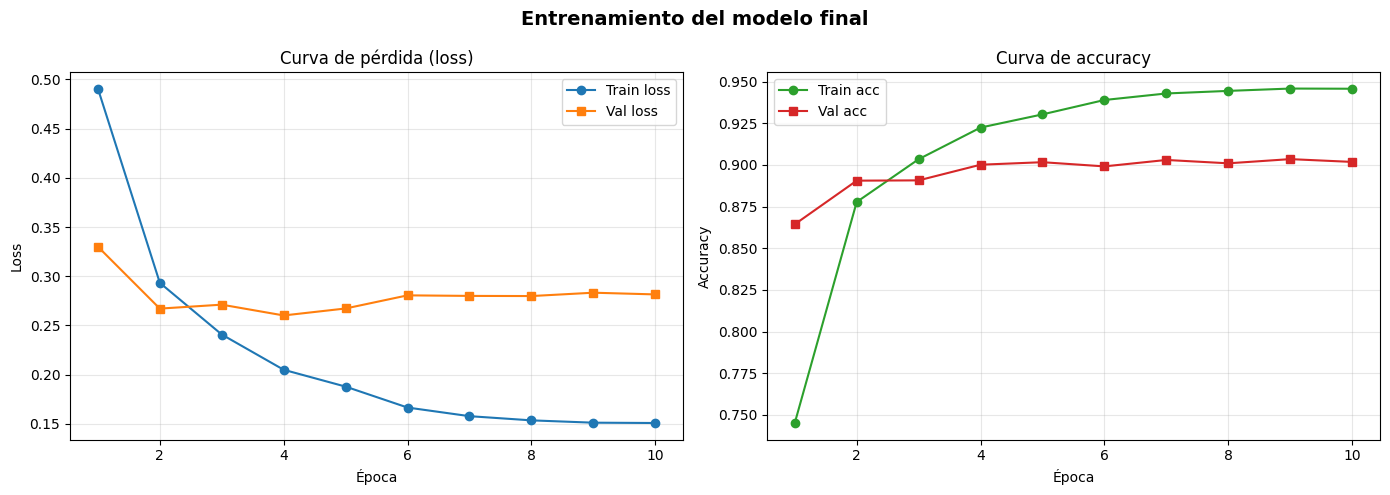

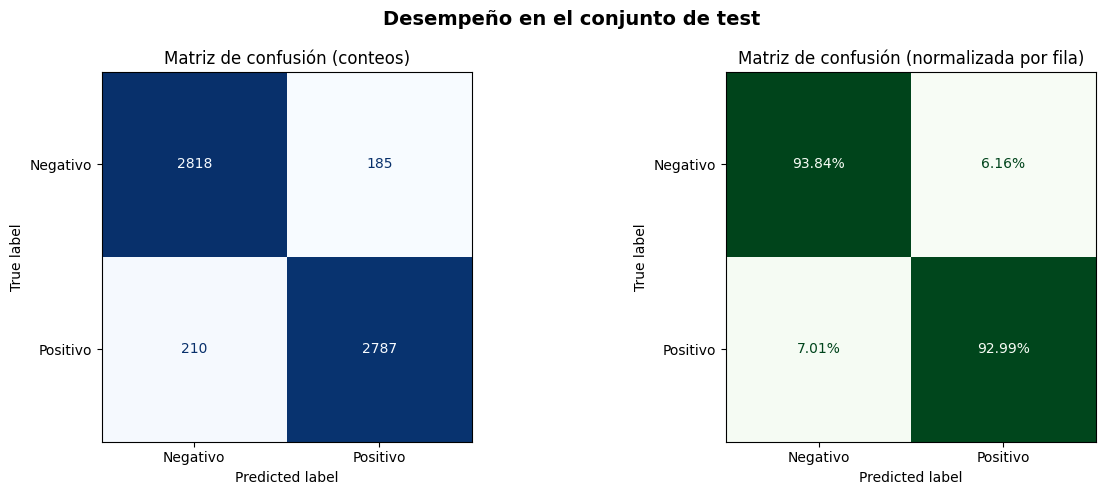

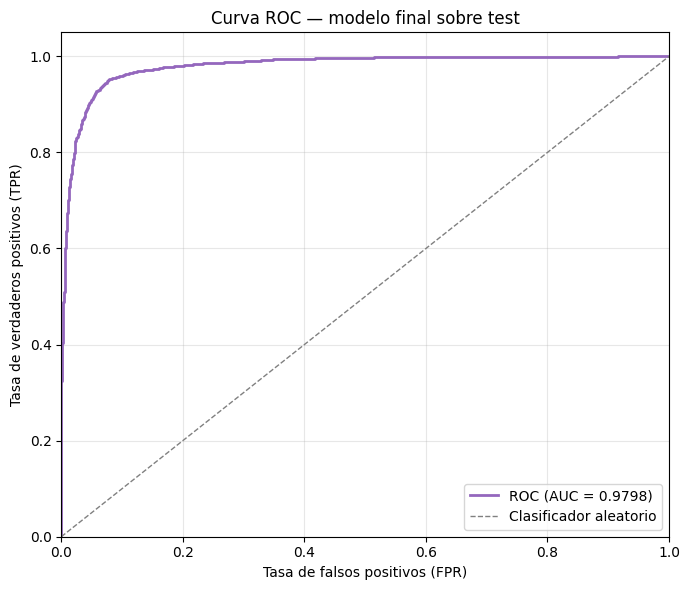

           CLASSIFICATION REPORT (test)
              precision    recall  f1-score   support

    Negativo     0.9306    0.9384    0.9345      3003
    Positivo     0.9378    0.9299    0.9338      2997

    accuracy                         0.9342      6000
   macro avg     0.9342    0.9342    0.9342      6000
weighted avg     0.9342    0.9342    0.9342      6000

  TN=2818  FP=185  FN=210  TP=2787
  Accuracy: 0.9342   AUC ROC: 0.9798


In [37]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, classification_report, roc_curve, auc, ConfusionMatrixDisplay,
)

# ---------- Curvas de entrenamiento (solo si final_history está disponible) ----------
if "final_history" in dir() and hasattr(final_history, "history"):
    hist = final_history.history
    epochs = range(1, len(hist["loss"]) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(epochs, hist["loss"],     "o-", label="Train loss", color="#1f77b4")
    axes[0].plot(epochs, hist["val_loss"], "s-", label="Val loss",   color="#ff7f0e")
    axes[0].set_title("Curva de pérdida (loss)")
    axes[0].set_xlabel("Época"); axes[0].set_ylabel("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(epochs, hist["accuracy"],     "o-", label="Train acc", color="#2ca02c")
    axes[1].plot(epochs, hist["val_accuracy"], "s-", label="Val acc",   color="#d62728")
    axes[1].set_title("Curva de accuracy")
    axes[1].set_xlabel("Época"); axes[1].set_ylabel("Accuracy"); axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.suptitle("Entrenamiento del modelo final", fontsize=14, fontweight="bold")
    plt.tight_layout(); plt.show()
else:
    print("ℹ️  `final_history` no está en memoria — se omiten las curvas de entrenamiento.")
    print("   (Para verlas habría que reentrenar; las matrices y la ROC sí funcionan).")

# ---------- Matriz de confusión ----------
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Negativo", "Positivo"]) \
    .plot(ax=axes[0], cmap="Blues", colorbar=False, values_format="d")
axes[0].set_title("Matriz de confusión (conteos)"); axes[0].grid(False)
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Negativo", "Positivo"]) \
    .plot(ax=axes[1], cmap="Greens", colorbar=False, values_format=".2%")
axes[1].set_title("Matriz de confusión (normalizada por fila)"); axes[1].grid(False)
plt.suptitle("Desempeño en el conjunto de test", fontsize=14, fontweight="bold")
plt.tight_layout(); plt.show()

# ---------- Curva ROC ----------
fpr, tpr, _ = roc_curve(y_true, y_proba)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, lw=2, color="#9467bd", label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], "--", color="gray", lw=1, label="Clasificador aleatorio")
plt.xlim([0, 1]); plt.ylim([0, 1.05])
plt.xlabel("Tasa de falsos positivos (FPR)"); plt.ylabel("Tasa de verdaderos positivos (TPR)")
plt.title("Curva ROC — modelo final sobre test")
plt.legend(loc="lower right"); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

# ---------- Reporte ----------
print("=" * 60); print("           CLASSIFICATION REPORT (test)"); print("=" * 60)
print(classification_report(y_true, y_pred, target_names=["Negativo", "Positivo"], digits=4))
tn, fp, fn, tp = cm.ravel()
print(f"  TN={tn}  FP={fp}  FN={fn}  TP={tp}")
print(f"  Accuracy: {(tp+tn)/cm.sum():.4f}   AUC ROC: {roc_auc:.4f}")


### 9. Ejemplos donde el modelo se equivoca


In [38]:
# Ejemplos mal clasificados
mis_idx = np.where(y_pred != y_true)[0]
print(f"Total de errores: {len(mis_idx)} de {len(y_true)} ({len(mis_idx)/len(y_true)*100:.2f}%)")

fp_idx = mis_idx[y_true[mis_idx] == 0]   # real=neg, pred=pos
fn_idx = mis_idx[y_true[mis_idx] == 1]   # real=pos, pred=neg

# Ordenar por confianza errónea
fp_idx = fp_idx[np.argsort(-y_proba[fp_idx])]
fn_idx = fn_idx[np.argsort( y_proba[fn_idx])]

X_test_text_arr = np.asarray(X_test_text)

def mostrar(idx_arr, titulo, n=3):
    print("\n" + "=" * 78)
    print(f"  {titulo}  (mostrando {min(n, len(idx_arr))} de {len(idx_arr)})")
    print("=" * 78)
    for k, i in enumerate(idx_arr[:n], 1):
        real_lbl = "POSITIVO" if y_true[i] == 1 else "NEGATIVO"
        pred_lbl = "POSITIVO" if y_pred[i] == 1 else "NEGATIVO"
        conf = abs(y_proba[i] - 0.5) * 2
        review = X_test_text_arr[i]
        if len(review) > 320:
            review = review[:320] + "..."
        print(f"\n[{k}] idx={i}  score={y_proba[i]:.4f}  confianza_error={conf*100:.1f}%")
        print(f"    Real     : {real_lbl}")
        print(f"    Predicho : {pred_lbl}   ← INCORRECTO")
        print(f"    Reseña   : {review}")

mostrar(fp_idx, "FALSOS POSITIVOS  (real=NEGATIVO, predicho=POSITIVO)", n=3)
mostrar(fn_idx, "FALSOS NEGATIVOS  (real=POSITIVO, predicho=NEGATIVO)", n=3)

# Resumen del peor error de cada tipo
peores = []
if len(fp_idx) > 0:
    i = fp_idx[0]
    peores.append({
        "Tipo": "Falso Positivo", "Real": "NEGATIVO", "Predicho": "POSITIVO",
        "Score": f"{y_proba[i]:.4f}",
        "Reseña (recortada)": X_test_text_arr[i][:120] + "...",
    })
if len(fn_idx) > 0:
    i = fn_idx[0]
    peores.append({
        "Tipo": "Falso Negativo", "Real": "POSITIVO", "Predicho": "NEGATIVO",
        "Score": f"{y_proba[i]:.4f}",
        "Reseña (recortada)": X_test_text_arr[i][:120] + "...",
    })

print("\n" + "=" * 78); print("  RESUMEN — peor error de cada tipo"); print("=" * 78)
print(pd.DataFrame(peores).to_string(index=False))


Total de errores: 395 de 6000 (6.58%)

  FALSOS POSITIVOS  (real=NEGATIVO, predicho=POSITIVO)  (mostrando 3 de 185)

[1] idx=72  score=0.9973  confianza_error=99.5%
    Real     : NEGATIVO
    Predicho : POSITIVO   ← INCORRECTO
    Reseña   : i wont take too much time here just wanted to state that darkman is awesome i have all on dvd added these to my collection of dvd movie sets darkman ranks up there with the best like indiana jones aliens star wars die hard you get the point there isn't too many good horror thriller sets out there many thanks to the who...

[2] idx=5445  score=0.9971  confianza_error=99.4%
    Real     : NEGATIVO
    Predicho : POSITIVO   ← INCORRECTO
    Reseña   : stranger than fiction angered me so much i signed up on imdb just to write this review stranger than fiction is a surprisingly complex touching and thought provoking movie until the very end once you suspend multiple lapses of logic why didn't will ferrell hear emma thompson's voice years ago when she f